In [1]:
import numpy as np
import ROOT
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
from scipy.interpolate import interp1d

In [10]:
plt.style.use(hep.style.CMS)

In [3]:
def log_interp1d(xx, yy, kind="linear"):
    logx = np.log(xx)
    logy = np.log(yy)
    lin_interp = interp1d(
        logx, logy, bounds_error=False, fill_value="extrapolate", kind=kind
    )
    log_interp = lambda zz: np.power(np.e, lin_interp(np.log(zz)))
    return log_interp


def get_quantiles(tree, scale):
    # Import branches
    limits = tree["limit"].array(library="np")
    mS = tree["mh"].array(library="np")
    quantiles = tree["quantileExpected"].array(library="np")

    # Get the quantiles
    masses = mS[quantiles == 0.025]
    qt_0p025 = limits[quantiles == 0.025]
    qt_0p16 = limits[quantiles == 0.16]
    qt_0p5 = limits[quantiles == 0.5]
    qt_0p84 = limits[quantiles == 0.84]
    qt_0p975 = limits[quantiles == 0.975]

    # Make sure these are sorted by mS
    sort_by_mass = np.argsort(masses)
    masses = masses[sort_by_mass]
    qt_0p025 = qt_0p025[sort_by_mass]
    qt_0p16 = qt_0p16[sort_by_mass]
    qt_0p5 = qt_0p5[sort_by_mass]
    qt_0p84 = qt_0p84[sort_by_mass]
    qt_0p975 = qt_0p975[sort_by_mass]

    # Convert signal strength to CL
    cross_sections = {
        125: 45.2,
        200: 16.9,
        300: 6.59,
        400: 3.19,
        500: 1.71,
        600: 1.0,
        800: 0.402,
        1000: 0.185,
    }
    for i, mS in enumerate(masses):
        qt_0p025[i] *= cross_sections[mS] / scale
        qt_0p16[i] *= cross_sections[mS] / scale
        qt_0p5[i] *= cross_sections[mS] / scale
        qt_0p84[i] *= cross_sections[mS] / scale
        qt_0p975[i] *= cross_sections[mS] / scale

    # Smoothen CLs
    cl_0p025_smooth = log_interp1d(masses, qt_0p025)
    cl_0p16_smooth = log_interp1d(masses, qt_0p16)
    cl_0p5_smooth = log_interp1d(masses, qt_0p5)
    cl_0p84_smooth = log_interp1d(masses, qt_0p84)
    cl_0p975_smooth = log_interp1d(masses, qt_0p975)

    return (
        masses,
        qt_0p5,
        (
            cl_0p025_smooth,
            cl_0p16_smooth,
            cl_0p5_smooth,
            cl_0p84_smooth,
            cl_0p975_smooth,
        ),
    )

In [4]:
input_path = "/uscms/home/chpapage/nobackup/SUEPs/MuonTriggers/combine_stuff/Nov2024/CMSSW_11_3_4/src"
f_leptonic = uproot.open(f"{input_path}/higgsCombinemPhi8_T32_leptonic.HybridNew.root")
f_hadronic = uproot.open(f"{input_path}/higgsCombinemPhi8_T32_hadronic.HybridNew.root")

In [5]:
limits_tree_leptonic = f_leptonic["limit"]
limits_tree_hadronic = f_hadronic["limit"]

In [6]:
masses_leptonic, cl_0p5_leptonic, cl_smooth_leptonic = get_quantiles(
    limits_tree_leptonic, 5000
)
masses_hadronic, cl_0p5_hadronic, cl_smooth_hadronic = get_quantiles(
    limits_tree_hadronic, 200
)

In [7]:
mass_vals = np.linspace(100, 1050, 1000)

In [8]:
masses = np.array([125, 200, 300, 400, 500, 600, 800, 1000])
cross_sections = np.array([45.2, 16.9, 6.59, 3.19, 1.71, 1.0, 0.402, 0.185])
xs_spl = log_interp1d(masses, cross_sections)

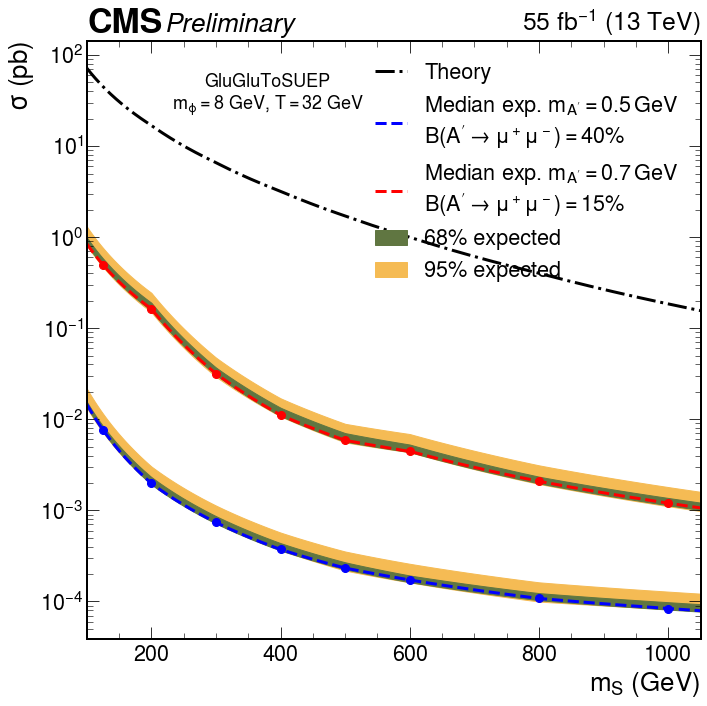

In [22]:
fig, ax = plt.subplots(figsize=(11, 11))

green = "#607641"
yellow = "#F5BB54"

# Theory
plt.plot(
    mass_vals, xs_spl(mass_vals), color="k", ls="-.", label="Theory", lw=3, zorder=4
)

# Plot median expected
plt.plot(masses_leptonic, cl_0p5_leptonic, color="b", marker="o", ms=8, ls="", zorder=3)
plt.plot(masses_hadronic, cl_0p5_hadronic, color="r", marker="o", ms=8, ls="", zorder=3)
plt.plot(
    mass_vals,
    cl_smooth_leptonic[2](mass_vals),
    color="b",
    ls="--",
    lw=3,
    label=r"Median exp. $m_{A'}=0.5\,GeV$"
    + "\n"
    + r"$B(A'\rightarrow\mu^+\mu^-)=40\%$",
    zorder=2,
)
plt.plot(
    mass_vals,
    cl_smooth_hadronic[2](mass_vals),
    color="r",
    ls="--",
    lw=3,
    label=r"Median exp. $m_{A'}=0.7\,GeV$"
    + "\n"
    + r"$B(A'\rightarrow\mu^+\mu^-)=15\%$",
    zorder=2,
)

# Plot bands
plt.fill_between(
    mass_vals,
    cl_smooth_leptonic[3](mass_vals),
    cl_smooth_leptonic[1](mass_vals),
    color=green,
    label="68% expected",
    zorder=1,
)
plt.fill_between(
    mass_vals,
    cl_smooth_leptonic[4](mass_vals),
    cl_smooth_leptonic[0](mass_vals),
    color=yellow,
    label="95% expected",
    zorder=0,
)

plt.fill_between(
    mass_vals,
    cl_smooth_hadronic[3](mass_vals),
    cl_smooth_hadronic[1](mass_vals),
    color=green,
    zorder=1,
)
plt.fill_between(
    mass_vals,
    cl_smooth_hadronic[4](mass_vals),
    cl_smooth_hadronic[0](mass_vals),
    color=yellow,
    zorder=0,
)

plt.legend(loc=1)
plt.xlim(100, 1050)
plt.yscale("log")
ax.set_xlabel(r"$m_{S}$ (GeV)")
ax.set_ylabel(r"$\sigma$ (pb)")
hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
plt.text(
    380, 25, "GluGluToSUEP\n$m_{\phi}=8$ GeV, $T=32$ GeV", ha="center", fontsize=18
)
plt.show()